In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Importing the dataset :-
Since data is in the form of excel file we have to use pandas read_excel to load the data
After loading it is important to check the complete information of data as it can indication many of the hidden infomation such as null values in a column or a row
Check whether any null values are there or not. if it is present then following can be done,
1. Imputing data using Imputation method in sklearn
2. Filling NaN values with mean, median and mode using fillna() method
3. Describe data --> which can give statistical analysis

In [2]:
df = pd.read_excel(r'D:\DataMites\Datamites Internship_proj\Flight Price Prediction\Flight_Fare.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df.shape

(10683, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [5]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [6]:
df1 = df.dropna() # its clear that there is no missing values
df1.shape

(10682, 11)

# EDA

From the dataset description, it is observed that the Date_of_Journey feature is stored as an object (string) data type. Since machine learning models cannot effectively interpret date information in string format, this column needs to be converted into a datetime (timestamp) format for proper feature extraction.

* To achieve this, the pandas.to_datetime() function is used to convert the object data type into a datetime data type.
* Once converted, useful components of the date can be extracted using the .dt accessor. Specifically, the .dt.day method is used to extract the day of the journey, and the .dt.month method is used to extract the month of the journey and .dt.year is used to extract the year of the Journey.
* we will use these extracted features from which the model better understand's the temporal patterns in flight pricing.

# Data Pre-processing and Feature Engineering

In [7]:
df1['Date_of_Journey'] = pd.to_datetime(df1['Date_of_Journey'], format='%d/%m/%Y')

df1['Day'] = df1['Date_of_Journey'].dt.day
df1['Month'] = df1['Date_of_Journey'].dt.month
df1['Year'] = df1['Date_of_Journey'].dt.year

In [8]:
df1[['Date_of_Journey', 'Day', 'Month', 'Year']].head()

,Date_of_Journey,Day,Month,Year
0,2019-03-24,24,3,2019
1,2019-05-01,1,5,2019
2,2019-06-09,9,6,2019
3,2019-05-12,12,5,2019
4,2019-03-01,1,3,2019


In [9]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [10]:
df1.shape

(10682, 14)

In [11]:
df1['Dep_Time'] = pd.to_datetime(df1['Dep_Time']) #converting the Departure tine to date time

# Extracting the Hour and Minute
df1['Dep_Hr'] = df1['Dep_Time'].dt.hour
df1['Dep_Min'] = df1['Dep_Time'].dt.minute


In [12]:
df1[['Dep_Hr', 'Dep_Min']].head()

,Dep_Hr,Dep_Min
0,22,20
1,5,50
2,9,25
3,18,5
4,16,50


In [13]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hr,Dep_Min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-01-07 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-01-07 05:50:00,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-01-07 09:25:00,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-01-07 18:05:00,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-01-07 16:50:00,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [14]:
df1.shape

(10682, 16)

In [15]:
df1.drop('Dep_Time', axis=1, inplace=True) # Droping the Original column as it is not required now

In [16]:
df1.shape

(10682, 15)

In [17]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hr,Dep_Min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [18]:
df1['Arrival_Time'].unique()

array(['01:10 22 Mar', '13:15', '04:25 10 Jun', ..., '06:50 10 Mar',
       '00:05 19 Mar', '21:20 13 Mar'], dtype=object)

### Using unique() will help us to discover hidden patterns, such as:
* Some values have date attached
* Some values have only time
* Inconsistent formatting
### To identify data cleaning we need
* Arrival time which sometimes includes next-day or next-month info
Example:

01:10 22 Mar

* which Means flight arrives next day which we have to clean this before extracting into hour/minute.
* and to prevent error later

In [19]:
df1['Arrival_Time'] = df1['Arrival_Time'].str.split(' ').str[0] #Removing the date part (keeping only time)

# Converting to datetime and extracting the features
df1['Arrival_Time'] = pd.to_datetime(df1['Arrival_Time'])

df1['Arr_Hr'] = df1['Arrival_Time'].dt.hour
df1['Arr_Min'] = df1['Arrival_Time'].dt.minute


In [20]:
df1.shape

(10682, 17)

In [21]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-01-07 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-01-07 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-01-07 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25,4,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-01-07 23:30:00,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-01-07 21:35:00,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [22]:
df1.drop('Arrival_Time', axis=1, inplace=True)

* Droping the Arrival_Time Col as no need now

In [23]:
df1.shape

(10682, 16)

In [24]:
df1["Duration"].value_counts()

Duration
2h 50m     550
1h 30m     386
2h 45m     337
2h 55m     337
2h 35m     329
          ... 
31h 30m      1
30h 25m      1
42h 5m       1
4h 10m       1
47h 40m      1
Name: count, Length: 368, dtype: int64

* In this step we will check unique value in the "Duration" column where we check the frequency, many times it appears.

In [25]:
# Extracting Hours and Minutes
df1['Duration'] = df1['Duration'].str.replace('h', 'h ').replace('m', 'm ')

In [26]:
# Time taken by plane to reach destination is called Duration
# It is the differnce betwwen Departure Time and Arrival time


# Assigning and converting Duration column into list
duration = list(df1["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [27]:
# Adding duration_hours and duration_mins list to train_data dataframe

df1["Duration_Hr"] = duration_hours
df1["Duration_Min"] = duration_mins

In [28]:
df1.shape

(10682, 18)

In [29]:
df1.head()

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,1,10,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35,4,45


In [30]:
df1.drop(["Duration"], axis = 1, inplace = True) # "Duration" column is not required now

In [31]:
df1.shape

(10682, 17)

In [32]:
# Since we had converted Date_of_Journey column into integers, Now we can drop as it is of no use.

df1.drop(["Date_of_Journey"], axis = 1, inplace = True)

In [33]:
df1.shape

(10682, 16)

# Encoding

* We need to handle the categorical data because in the datset there are Nominal and Ordinal data which we need to handle.
* For *Nominal Data* we will use "OneHotEncoder" and for *Ordinal Data* we will use "LabelEncoder".
* Since, several features in the dataset such as Airline, Source, and Destination are categorical (object type). These categorical variables cannot be directly used for model training, so they must be converted into numerical form through encoding.
* ML model requires Numerical input.

In [34]:
df1["Airline"].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

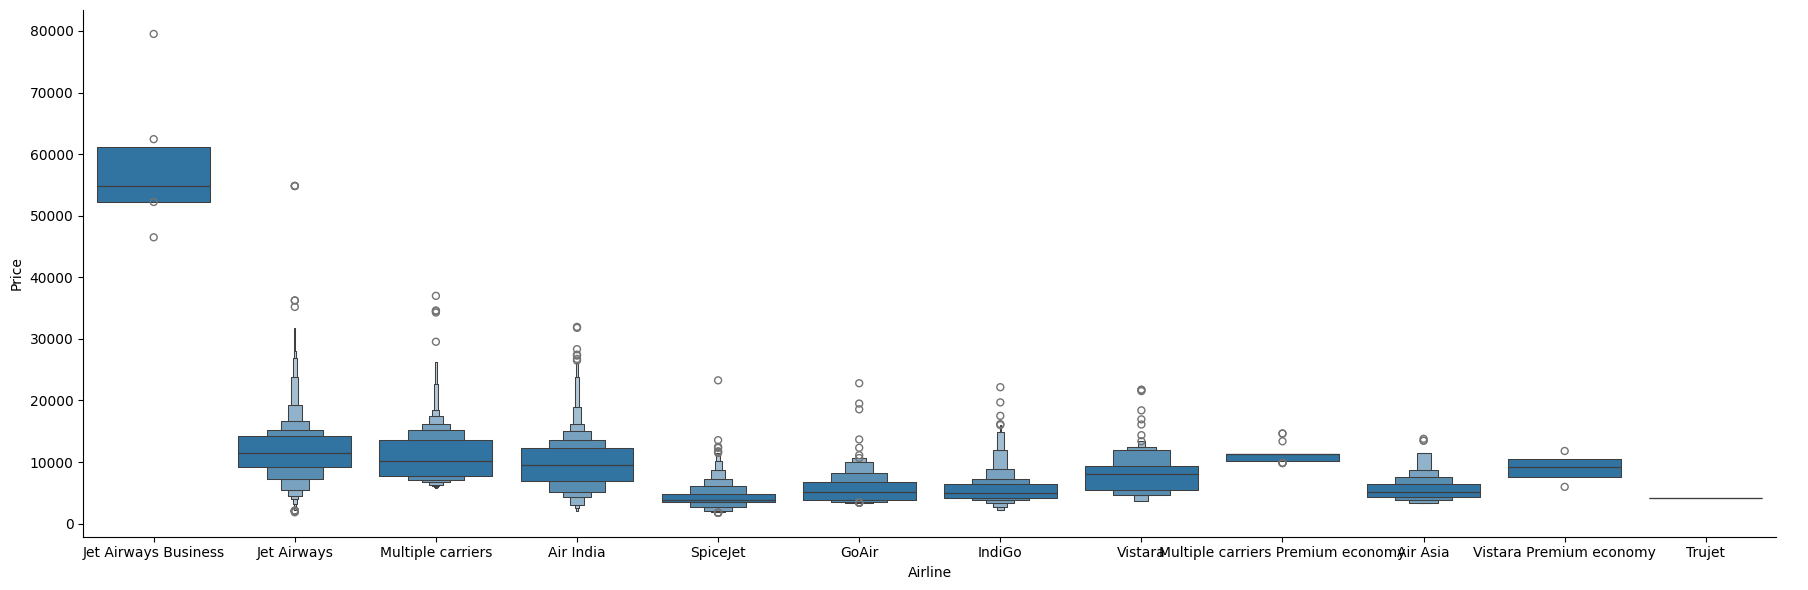

In [35]:
# From graph we can see that Jet Airways Business have the highest Price.
# Apart from the first Airline almost all are having similar median

# Airline vs Price
sns.catplot(y = "Price", x = "Airline", data = df1.sort_values("Price", ascending = False), kind="boxen", height = 6, aspect = 3)
plt.show()

In [36]:
# As Airline is Nominal Categorical data we will perform OneHotEncoding

Airline = df1[["Airline"]]

# Applying One-Hot Encoding
Airline = pd.get_dummies(Airline, drop_first= True)

Airline.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [37]:
# The Source feature represents the departure city and is a nominal categorical variable with no inherent order.
df1["Source"].value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

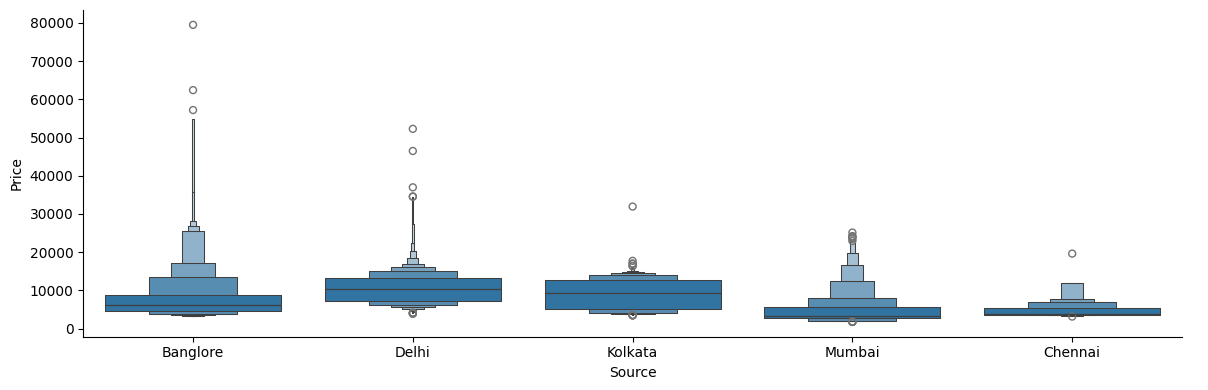

In [38]:
# Source vs Price

sns.catplot(y = "Price", x = "Source", data = df1.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3)
plt.show()

In [39]:
# As Source is Nominal Categorical data we will perform OneHotEncoding

Source = df1[["Source"]]

Source = pd.get_dummies(Source, drop_first= True)

Source.head()

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [40]:
# The Destination feature represents the arrival city and is a nominal categorical variable with no inherent order.
df1["Destination"].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [41]:
# As Destination is Nominal Categorical data we will perform OneHotEncoding

Destination = df1[["Destination"]]

Destination = pd.get_dummies(Destination, drop_first = True)

Destination.head()

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [42]:
# Route represents the path taken by the flight
df1["Route"]

0                    BLR → DEL
1        CCU → IXR → BBI → BLR
2        DEL → LKO → BOM → COK
3              CCU → NAG → BLR
4              BLR → NAG → DEL
                 ...          
10678                CCU → BLR
10679                CCU → BLR
10680                BLR → DEL
10681                BLR → DEL
10682    DEL → GOI → BOM → COK
Name: Route, Length: 10682, dtype: object

In [43]:
df1["Additional_Info"]

0        No info
1        No info
2        No info
3        No info
4        No info
          ...   
10678    No info
10679    No info
10680    No info
10681    No info
10682    No info
Name: Additional_Info, Length: 10682, dtype: object

* The Route feature is dropped because it has high cardinality and contains redundant information already captured by Source, Destination, and Total_Stops, which helps prevent model complexity and overfitting.
* And the Additional_Info feature is also droped because it contains largely uninformative and noisy textual data, offering minimal predictive value.

In [44]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other

df1.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [45]:
df1["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

* This feature has a natural order, so One-Hot Encoding is NOT ideal.
* and since, the number of stops increases logically so, we will convert it into numeric values.

In [46]:
# As this is case of Ordinal Categorical type we perform LabelEncoder
# Here Values are assigned with corresponding keys

df1.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

In [47]:
df1['Total_Stops'].value_counts()

Total_Stops
1    5625
0    3491
2    1520
3      45
4       1
Name: count, dtype: int64

In [48]:
df1.head()

,Airline,Source,Destination,Total_Stops,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [49]:
df1.shape

(10682, 14)

In [50]:
# Concatenate dataframe --> train_data + Airline + Source + Destination

data_train = pd.concat([df1, Airline, Source, Destination], axis = 1)

In [51]:
data_train.head()

,Airline,Source,Destination,Total_Stops,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [52]:
Airline = pd.get_dummies(df1[['Airline']], drop_first=True, dtype=int)
Source = pd.get_dummies(df1[['Source']], drop_first=True, dtype=int)
Destination = pd.get_dummies(df1[['Destination']], drop_first=True, dtype=int)

In [53]:
data_train = pd.concat([df1, Airline, Source, Destination], axis=1)

In [54]:
data_train.head()

,Airline,Source,Destination,Total_Stops,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [55]:
data_train.shape

(10682, 34)

### Above we have done and preprocess of the dataset and converted it into machine redable data, which was in the categorical form and now changed in numerical form.

# Analysis and Visualization

In [56]:
data_train.describe()

,Total_Stops,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
count,10682.000000,10682.000000,10682.000000,10682.000000,10682.0,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000,10682.000000
mean,0.824190,9087.214567,13.509081,4.708575,2019.0,12.491013,24.409287,13.349186,24.690601,10.244898,28.326624,0.163921,0.018161,0.192192,0.360326,0.000562,0.111964,0.001217,0.076577,0.000094,0.044842,0.000281,0.035667,0.424640,0.268770,0.065250,0.424640,0.118424,0.065250,0.035667,0.087250
std,0.675229,4611.548810,8.479363,1.164408,0.0,5.748820,18.767801,6.859317,16.506808,8.494916,16.945817,0.370221,0.133541,0.394042,0.480117,0.023695,0.315337,0.034866,0.265932,0.009676,0.206966,0.016757,0.185468,0.494311,0.443341,0.246978,0.494311,0.323124,0.246978,0.185468,0.282214
min,0.000000,1759.000000,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5277.000000,6.000000,3.000000,2019.0,8.000000,5.000000,8.000000,10.000000,2.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,8372.000000,12.000000,5.000000,2019.0,11.000000,25.000000,14.000000,25.000000,8.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,12373.000000,21.000000,6.000000,2019.0,18.000000,40.000000,19.000000,35.000000,15.000000,45.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,79512.000000,27.000000,6.000000,2019.0,23.000000,55.000000,23.000000,55.000000,47.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Now we will visualize the data and understand it with some graph

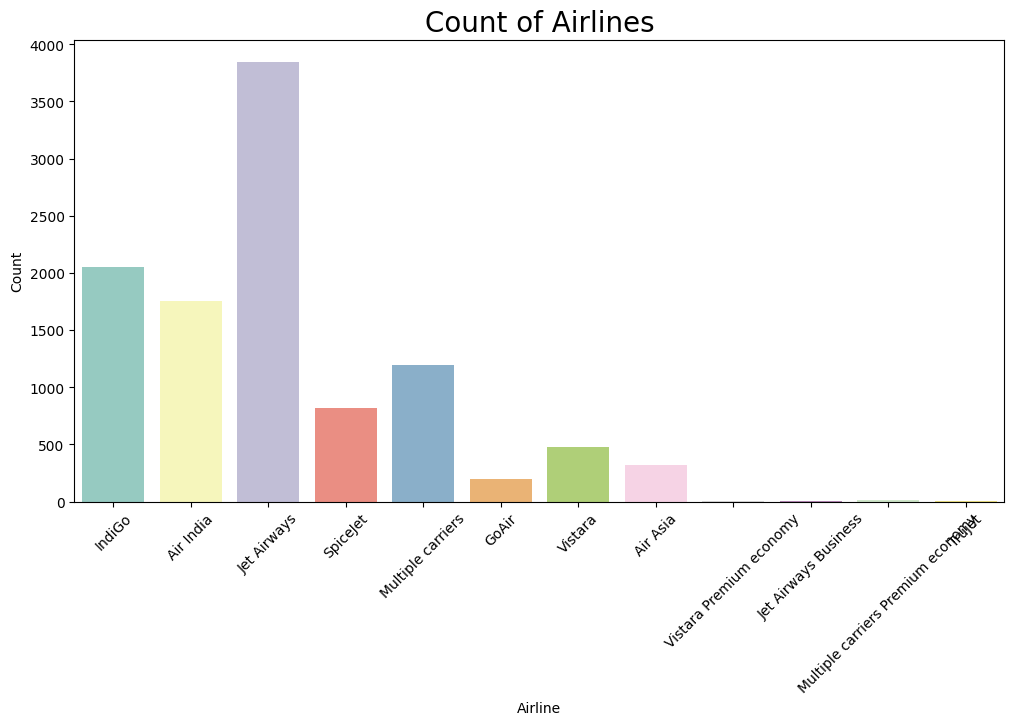

In [57]:
plt.figure(figsize=(12,6))
sns.countplot(x='Airline', data=data_train, palette='Set3')
plt.title('Count of Airlines', fontsize=20)
plt.xlabel('Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

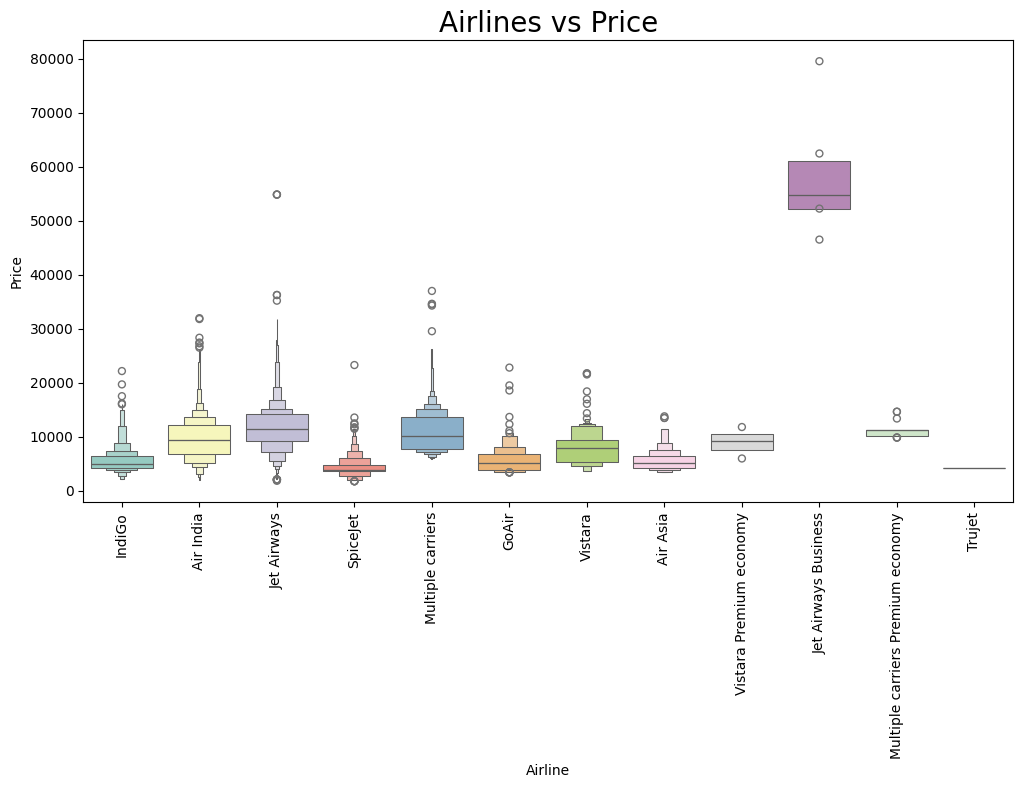

In [58]:
plt.figure(figsize=(12,6))
sns.boxenplot(
    x='Airline',
    y='Price',
    data=data_train,
    palette='Set3'
)
plt.title('Airlines vs Price', fontsize=20)
plt.xticks(rotation=90)
plt.show()


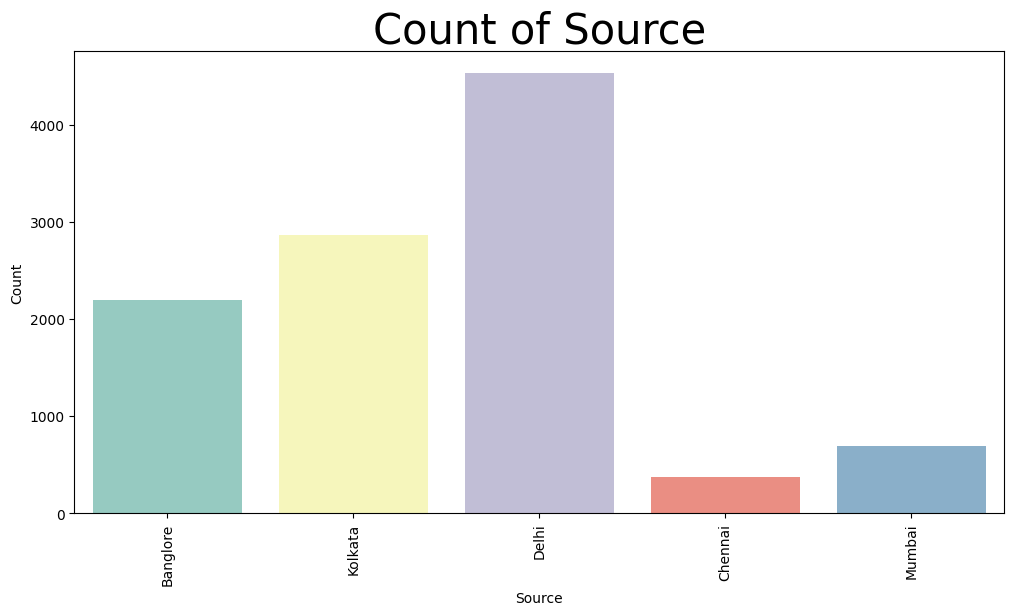

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(x='Source', data=data_train, palette='Set3')
plt.title('Count of Source', size=30)
plt.xlabel('Source')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

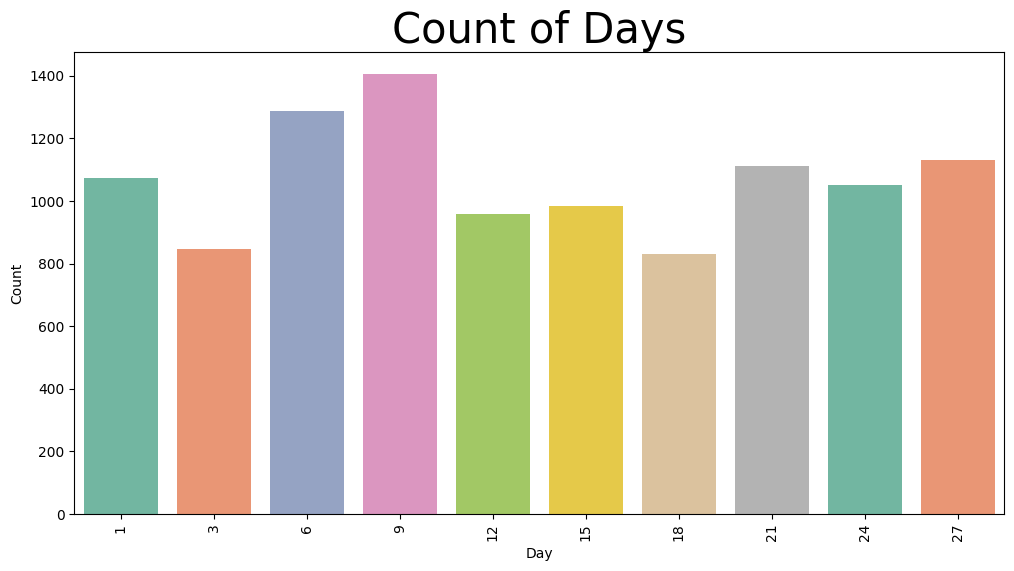

In [60]:
plt.figure(figsize=(12,6))
sns.countplot(x='Day',data= data_train, palette='Set2')
plt.title('Count of Days', size=30)
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

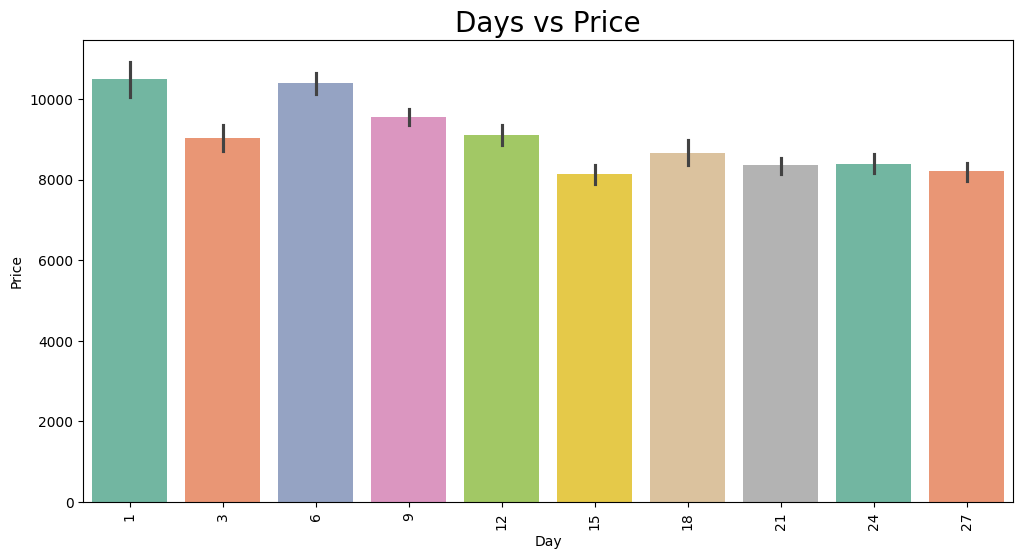

In [61]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='Day',
    y='Price',
    data=data_train,
    palette='Set2'
)
plt.title('Days vs Price', fontsize=20)
plt.xticks(rotation=90)
plt.show()


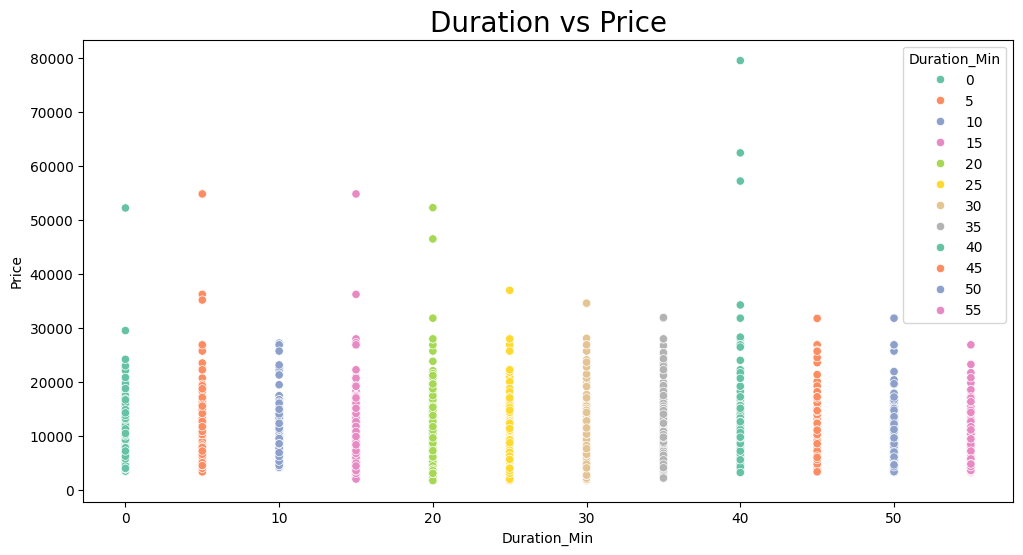

In [62]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    x='Duration_Min',
    y='Price',
    data=data_train,
    hue='Duration_Min',
    palette='Set2'
)
plt.title('Duration vs Price', fontsize=20)
plt.show()


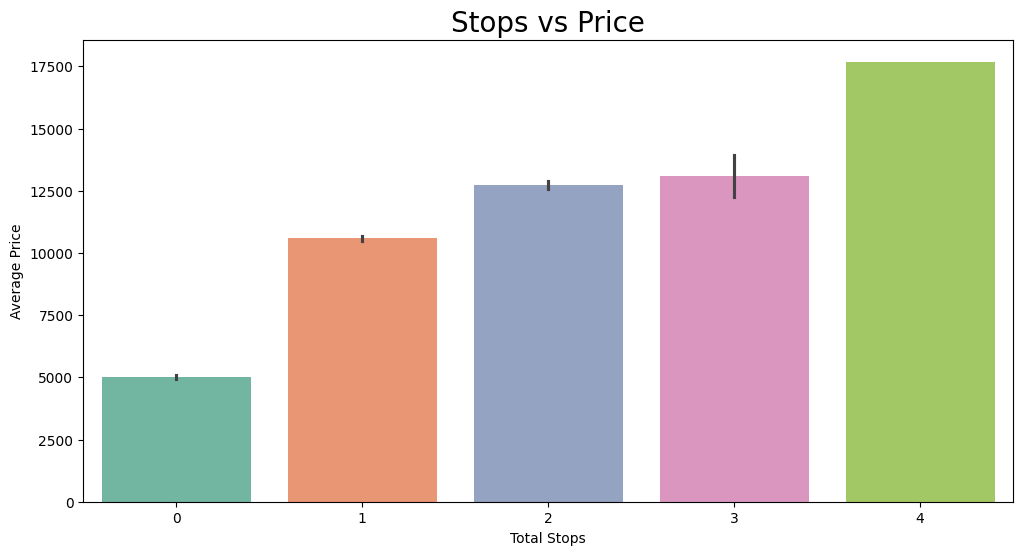

In [63]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='Total_Stops',
    y='Price',
    data=data_train,
    palette='Set2'
)
plt.title('Stops vs Price', fontsize=20)
plt.xlabel('Total Stops')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

### Skewness & Kurtosis

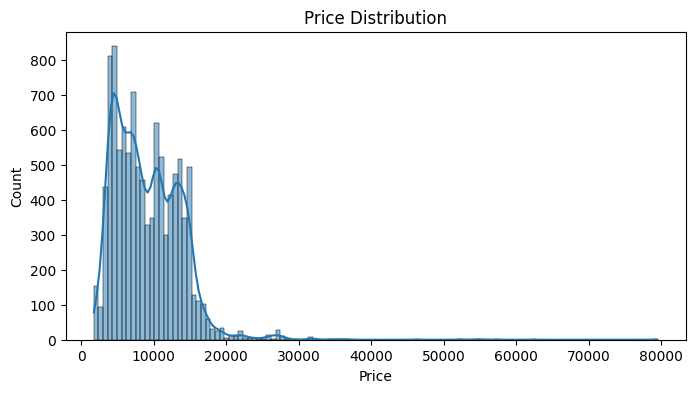

In [64]:
plt.figure(figsize=(8,4))
sns.histplot(data_train['Price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [65]:
print("Skewness :", data_train['Price'].skew())
print("Kurtosis :", data_train['Price'].kurt())

Skewness : 1.812404554693161
Kurtosis : 13.3019367653792


In [66]:
data_train['Price_log'] = np.log1p(data_train['Price'])

In [67]:
print("Skewness after log:", data_train['Price_log'].skew())
print("Kurtosis after log:", data_train['Price_log'].kurt())

Skewness after log: -0.25459160172898476
Kurtosis after log: -0.4024640012997547


In [68]:
data_train.shape

(10682, 35)

In [69]:
data_train.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

* After One-Hot Encoding, the original categorical columns are dropped to avoid redundancy and ensure that the dataset contains only numerical features suitable for model training.

In [70]:
data_train.shape

(10682, 32)

In [71]:
data_train.head()

,Total_Stops,Price,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Price_log
0,0,3897,24,3,2019,22,20,1,10,2,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8.268219
1,2,7662,1,5,2019,5,50,13,15,7,25,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,8.944159
2,2,13882,9,6,2019,9,25,4,25,19,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,9.538420
3,1,6218,12,5,2019,18,5,23,30,5,25,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,8.735364
4,1,13302,1,3,2019,16,50,21,35,4,45,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,9.495745


# Feature Selection

Here we will find out the best feature which will contribute and have good relation with target variable. Following are some of the feature selection methods,

1. heatmap
2. feature_importance_
3. SelectKBest

In [72]:
data_train.columns

Index(['Total_Stops', 'Price', 'Day', 'Month', 'Year', 'Dep_Hr', 'Dep_Min',
       'Arr_Hr', 'Arr_Min', 'Duration_Hr', 'Duration_Min', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi', 'Price_log'],
      dtype='object')

In [73]:
X = data_train.loc[:, ['Total_Stops', 'Day', 'Month', 'Year', 'Dep_Hr', 'Dep_Min',
       'Arr_Hr', 'Arr_Min', 'Duration_Hr', 'Duration_Min', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi']]
X.head()
# we will remove Price and Price_log as one will be the target variable.

,Total_Stops,Day,Month,Year,Dep_Hr,Dep_Min,Arr_Hr,Arr_Min,Duration_Hr,Duration_Min,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,2019,22,20,1,10,2,50,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2,1,5,2019,5,50,13,15,7,25,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,2,9,6,2019,9,25,4,25,19,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
3,1,12,5,2019,18,5,23,30,5,25,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,1,1,3,2019,16,50,21,35,4,45,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [74]:
X = data_train.drop(['Price', 'Price_log'], axis=1)
y = data_train['Price_log']

In [75]:
y = data_train.iloc[:, 1]
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

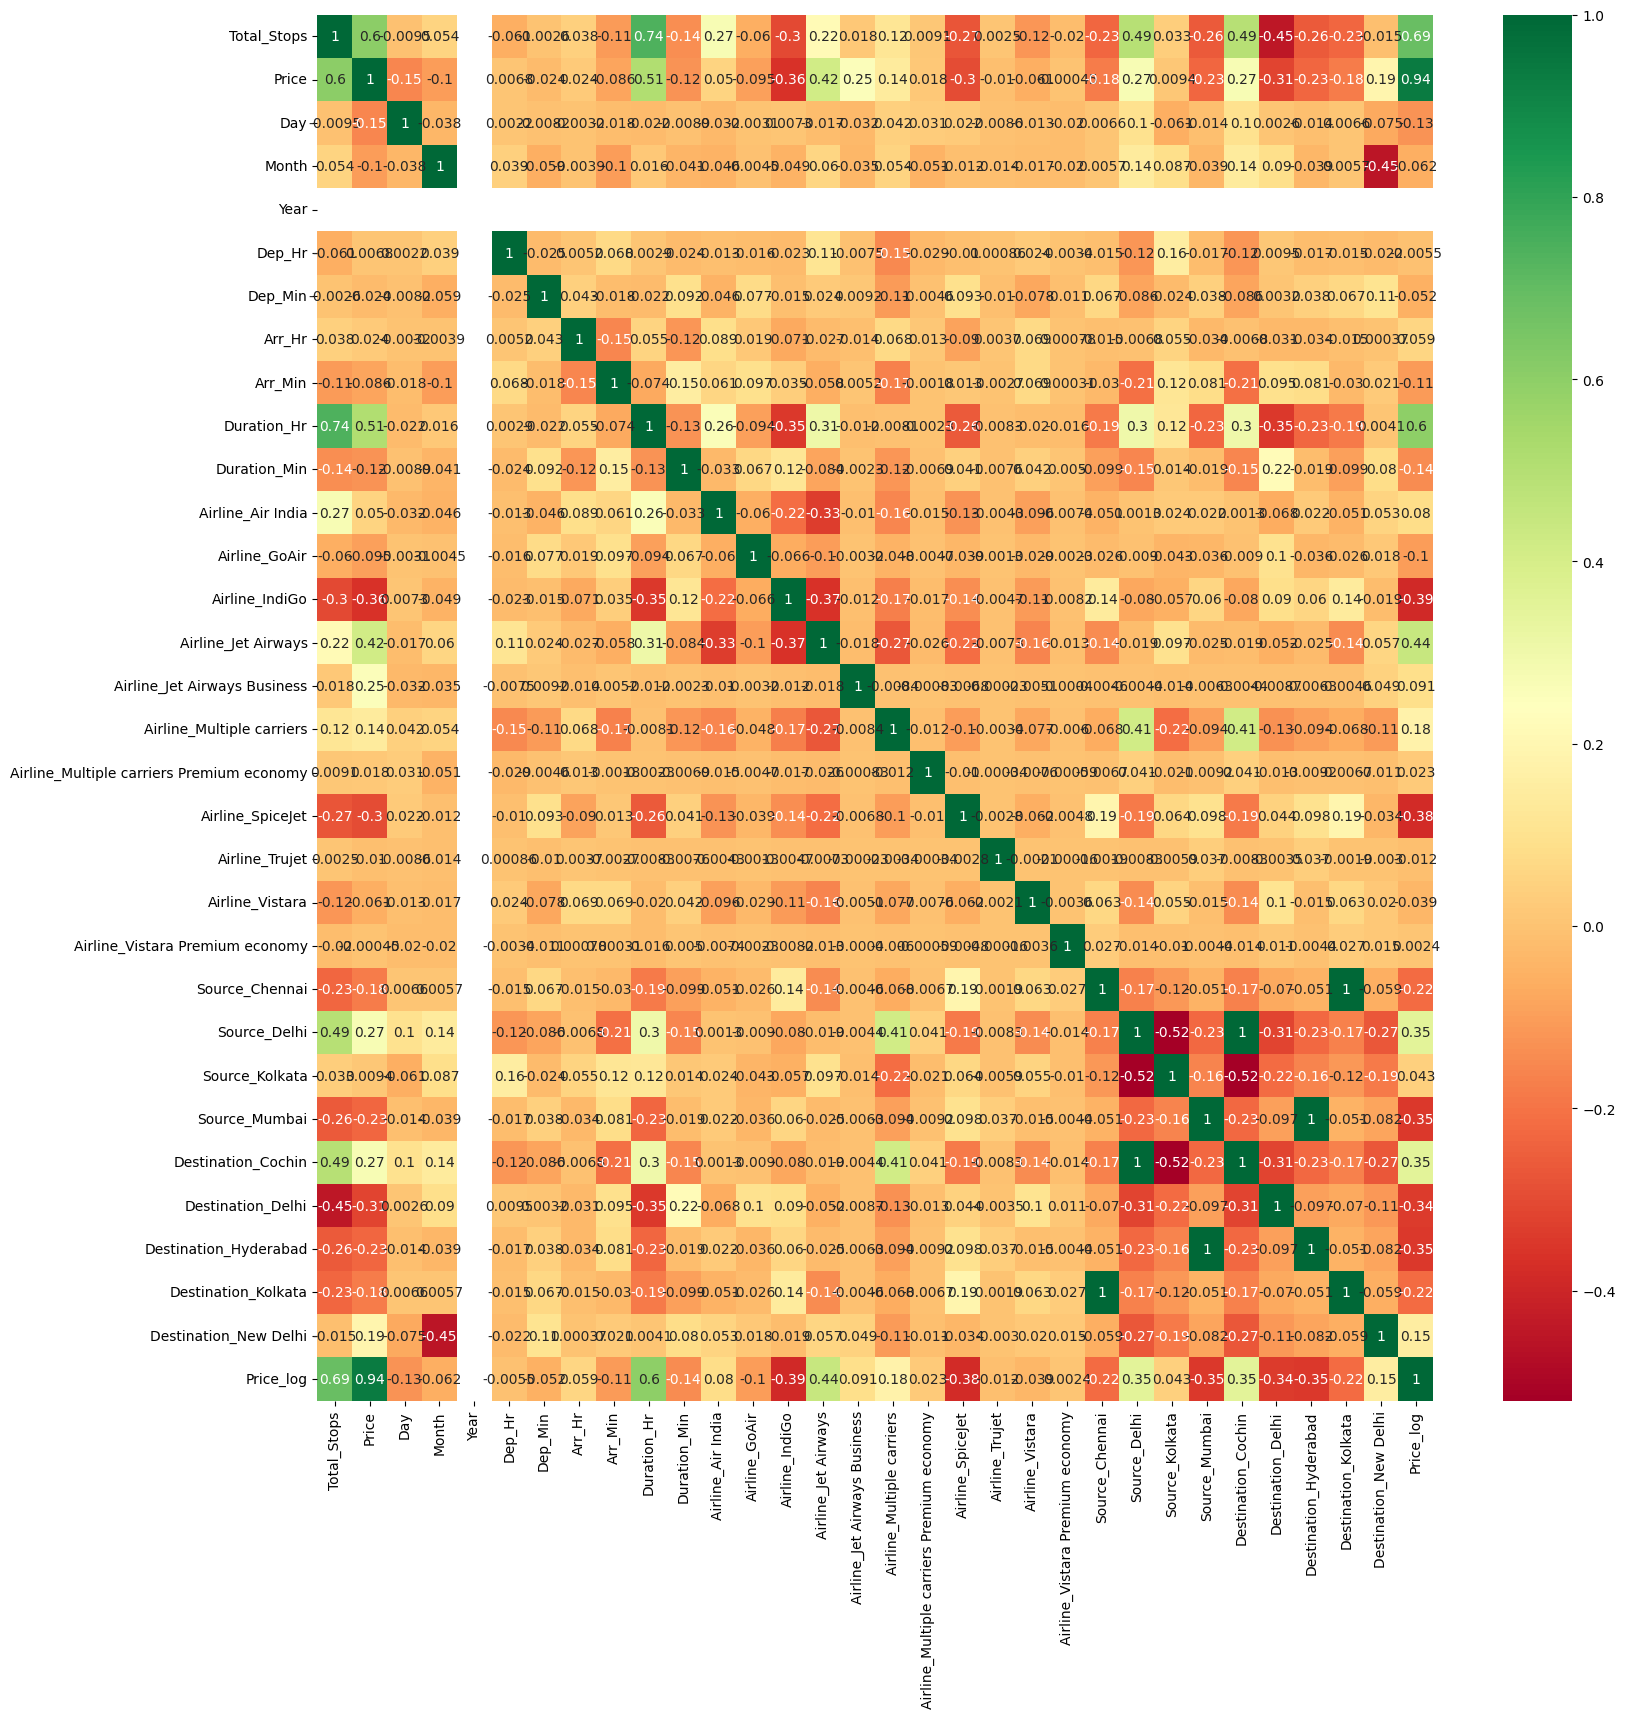

In [76]:
# Finds correlation between Independent and dependent attributes

plt.figure(figsize = (18,18))
sns.heatmap(data_train.corr(), annot = True, cmap = "RdYlGn")

plt.show()

* The correlation heatmap reveals that flight price is strongly influenced by the number of stops, flight duration, and airline type. Premium airlines and longer routes show positive correlation with price, while budget airlines exhibit negative correlation. Temporal features such as departure time and day show weak correlation, indicating limited impact on pricing. The Year feature was excluded due to zero variance. Overall, the selected features exhibit meaningful relationships with the target variable, validating the feature engineering process.

* Year column has only ONE unique value (i.e 2019) So, Correlation cannot be computed when a column has:
Zero variance (constant values)

In [77]:
df1['Year'].value_counts()

Year
2019    10682
Name: count, dtype: int64

In [78]:
# Important feature using ExtraTreesRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X, y)

ExtraTreesRegressor()

In [79]:
print(selection.feature_importances_)

[2.49797804e-01 1.43500994e-01 5.31800772e-02 0.00000000e+00
 2.42619876e-02 2.13941163e-02 2.85757893e-02 1.92354276e-02
 9.97086560e-02 1.74830952e-02 9.54790486e-03 1.98065404e-03
 1.86457434e-02 1.38901244e-01 6.73718208e-02 1.74829967e-02
 8.80818406e-04 3.19506248e-03 1.29988690e-04 4.99992840e-03
 8.74396959e-05 4.95165360e-04 8.80204766e-03 3.18399917e-03
 5.53269760e-03 1.45963780e-02 1.54142435e-02 5.92150570e-03
 6.21239114e-04 2.50711755e-02]


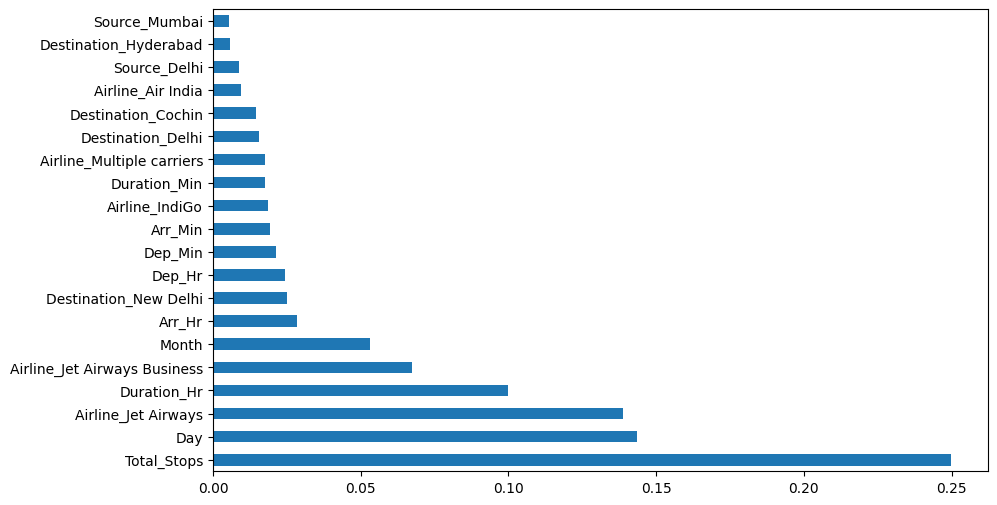

In [80]:
#plot graph of feature importances for better visualization

plt.figure(figsize = (10,6))
feat_importances = pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

* Feature importance analysis using a tree-based model revealed that the number of stops, flight duration, and airline type are the most influential factors in determining flight prices. Route-related features such as source and destination also contribute moderately, while temporal features like departure time and day have minimal impact. This confirms that pricing is primarily driven by flight complexity and service class rather than scheduling.

# Model Fitting
1) Split dataset into train and test set in order to prediction w.r.t X_test
2) If needed do scaling of data
    * Scaling is not done in Random forest
3) Import model
4) Fit the data
5) Predict w.r.t X_test
6) In regression check RSME Score
7) Plot graph

# Decision Tree

In [81]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Define X and y
X = data_train.drop(['Price', 'Price_log'], axis=1)
y = data_train['Price_log']

# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree model
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)
# fit the model
dt_model.fit(X_train, y_train)

# Predict on Test Data
y_pred_log = dt_model.predict(X_test)

In [82]:
# now converting Prediction back to original price
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred_log)

In [83]:
# Model Evaluation
r2 = r2_score(y_test_actual, y_pred_actual)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)

print("Decision Tree Regression Results")
print("--------------------------------")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")
print(f"RMSE     : {rmse:.2f}")

Decision Tree Regression Results
--------------------------------
R2 Score : 0.6648
MAE      : 1373.69
MSE      : 7227897.52
RMSE     : 2688.47


* “The Decision Tree Regressor achieved an R² score of 0.66, indicating moderate predictive performance. While the model captured key non-linear relationships, it showed higher error due to sensitivity to noise and overfitting tendencies. Ensemble models like Random Forest significantly improved performance by reducing variance.”

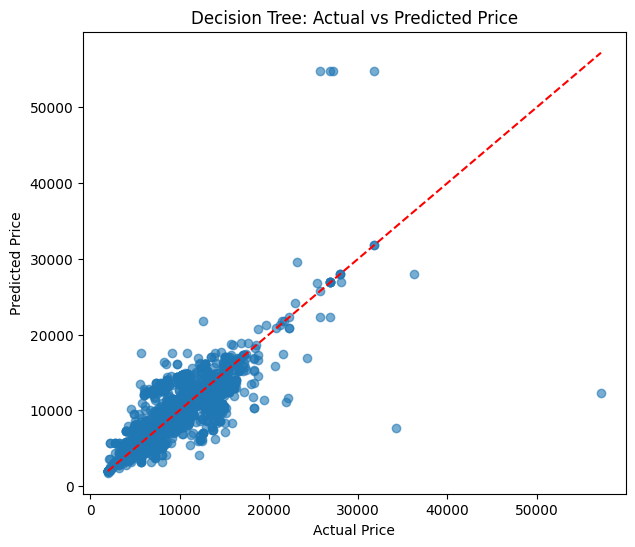

In [84]:
plt.figure(figsize=(7,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted Price")

# Reference diagonal line
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--'
)

plt.show()

# Random Forest

In [85]:
# 1. Train-test split
from sklearn.model_selection import train_test_split

# Features (remove both Price & Price_log)
X = data_train.drop(['Price', 'Price_log'], axis=1)

# Target (log-transformed price)
y = data_train['Price_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [87]:
import numpy as np

# Predict log price
y_pred_log = rf.predict(X_test)

# Convert back to actual price
y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print("Random Forest Results")
print("----------------------")
print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

Random Forest Results
----------------------
R2 Score : 0.7990347201741854
MAE      : 1168.851328816706
MSE      : 4333224.682805148
RMSE     : 2081.6399022898145


* “We trained the Random Forest on log-transformed prices to reduce skewness and converted predictions back to the original scale for evaluation, ensuring robust and leakage-free performance.”
* “Initially, very high R² scores indicated data leakage due to the inclusion of log-transformed target values in the feature set. After removing leakage and evaluating predictions on the original price scale, the Random Forest achieved an R² score of 0.80 with an RMSE of ₹2081, indicating strong and reliable performance.”

# MODEL COMPARISON

In [89]:
# Features and Target
#X = data_train.drop('Price', axis=1)
#y = data_train['Price']

In [90]:
X = data_train.drop(['Price', 'Price_log'], axis=1)
y = data_train['Price_log']

In [91]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [92]:
# Scaling for Linear, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [93]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.001)
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)


In [94]:
# FINAL MODEL COMPARISON
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

models = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():

    if name in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append([name, r2, mae, mse, rmse])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "MSE", "RMSE"]
)

results_df

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.729693,0.202742,0.073549,0.271199
1,Ridge Regression,0.729692,0.202746,0.073549,0.271199
2,Lasso Regression,0.728898,0.203304,0.073765,0.271597
3,Decision Tree,0.807766,0.140287,0.052306,0.228705
4,Random Forest,0.876313,0.121488,0.033654,0.183451


* “After applying log transformation to the target variable, model performance improved significantly. Random Forest achieved the highest R² score of 0.876 with the lowest MAE and RMSE, indicating superior predictive capability and generalization compared to linear and tree-based models.”

# Hyperparameter Tuning

In [95]:
X = data_train.drop(['Price', 'Price_log'], axis=1)
y = data_train['Price_log']

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [97]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [98]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [99]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [100]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

In [101]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("🔹 Tuned Random Forest Results")
print("------------------------------")
print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

🔹 Tuned Random Forest Results
------------------------------
R2 Score : 0.8749730272531668
MAE      : 0.13031322256620878
MSE      : 0.03401905687060984
RMSE     : 0.18444255710277344


* “Hyperparameter tuning using GridSearchCV significantly improved the Random Forest model. The tuned model achieved higher R² and lower error metrics, demonstrating better generalization and robustness compared to the default configuration.”

# Saving the model and Predicting Price 

In [102]:
import joblib
# Save the Model
joblib.dump(best_rf, "random_forest_price_model.pkl")

# Saving Feature Columns Order
joblib.dump(X.columns.tolist(), "model_features.pkl")

# Saving the Scaler which was used in Linear
joblib.dump(scaler, "scaler.pkl")

# Load the Saved Model for future use
loaded_model = joblib.load("random_forest_price_model.pkl")
feature_columns = joblib.load("model_features.pkl")


In [103]:
new_data = pd.DataFrame([{
    'Total_Stops': 1,
    'Duration_Hr': 2,
    'Duration_Min': 30,
    'Dep_Hr': 10,
    'Dep_Min': 15,
    'Arr_Hr': 12,
    'Arr_Min': 45,
    'Day': 15,
    'Month': 6,
    'Airline_IndiGo': 1,
    'Airline_Air India': 0,
    'Airline_Jet Airways': 0,
    'Source_Delhi': 1,
    'Source_Mumbai': 0,
    'Destination_New Delhi': 1
}])

In [104]:
new_data = new_data.reindex(columns=feature_columns, fill_value=0)

In [105]:
predicted_log_price = model.predict(new_data)
predicted_price = np.exp(predicted_log_price)

print("Predicted Price:", predicted_price[0])

Predicted Price: 6507.112647206192


* “We have predicted on new data on the same feature engineering and column order used during training, which must be applied further on the API endpoint for prediction. The trained Random Forest model predicts the target, and if log transformation was used, the output is converted back using exponential transformation.”

# Conclusion
* A flight price prediction system was built using multiple regression models. After preprocessing and log transformation to handle skewness, models were evaluated using R², MAE, MSE, and RMSE. Random Forest performed best, accurately capturing non-linear patterns and providing reliable predictions for new data after inverse log transformation.

### Challenges Faced
* Highly skewed price data (handled using log transformation)
* High-dimensional categorical features due to one-hot encoding
* Overfitting in Decision Tree models
* Maintaining consistent preprocessing for new data prediction
* Balancing model accuracy vs computational cost
